# **CLASE 05: Herramientas de visualización de datos**
## Medidas estadisticas, histogramas, scatters (Python)

# **1. Preparar el entorno y cargar los datos**

## **1.1. Cargar librerias desde el entorno Colab**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **1.2. Cargar datos desde el Repositorio**

[StudentsPerformance.csv](https://github.com/estebangonzalezITM/DataScience/blob/main/MaterialdeEstudio/Semana5/StudentsPerformance.csv)


In [ ]:
# Ruta del archivo CSV
url = 'https://raw.githubusercontent.com/estebangonzalezITM/DataScience/main/MaterialdeEstudio/Semana5/StudentsPerformance.csv'

# Cargar el archivo CSV en un DataFrame de nombre 'df'
df = pd.read_csv(url)

# Mostar el DataFrame
#df
#df.head()

# **2. Exploración del dataset**
## **2.1. Algunas Medidas Estadisticas**

In [ ]:
# Mostar información de DataFrame
df.info()

In [ ]:
# Mostrar información estadística del Dataframe
df.describe()

## **2.2. Explorar el dataset**

In [ ]:
# Mostrar las primeras 5 filas del dataframe
df.head()

In [ ]:
# Mostrar las últimas 5 filas del dataframe
df.tail()

In [ ]:
# Mostrar el "tamaño" del dataframe
df.shape

In [ ]:
# Mostrar las columnas del dataframe
df.columns

In [ ]:
# Mostrar el tipo de elementos de cada columna del dataframe
df.dtypes

# **3. Visualizar la frecuencia de los datos mediante graficos como histogramas**

## **3.1. Graficar todos los histogramas con un ciclo**

In [ ]:
# Obtener una lista de todas las columnas en tu DataFrame 'data'
columnas = df.columns

# Iterar sobre cada columna y graficar su distribución usando la librería seaborn
for columna in columnas:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[columna], kde=False, color='blue', edgecolor='black')
    plt.xlabel(columna)                      # Etiqueta del eje x con el nombre de la columna
    plt.ylabel('Conteo')                     # Etiqueta del eje y
    plt.title(f'Distribución de {columna}')  # Título del gráfico con el nombre de la columna
    plt.show()


## **3.2. Graficar solo los histogramas de 'interés' para el análisis**

In [ ]:
# Histograma de los resultados del test de matemáticas
sns.histplot(df['math score'].dropna(), kde=True)
plt.title('math score')
plt.show()

In [ ]:
# Histograma de los resultados del test de lectura
sns.histplot(df['reading score'].dropna(), kde=True)
plt.title('Reading score')
plt.show()

In [ ]:
# Histograma de los resultados del test de escritura
sns.histplot(df['writing score'].dropna(), kde=True)
plt.title('Writing score')
plt.show()

## **3.3. Modificar el ancho de las columnas del histograma usando el parámetro `bins`**

In [ ]:
sns.histplot(df['math score'].dropna(), kde=True, bins=10)
plt.title('math score')
plt.show()

In [ ]:
sns.histplot(df['math score'].dropna(), kde=True, bins=20)
plt.title('math score')
plt.show()

In [ ]:
sns.histplot(df['math score'].dropna(), kde=True, bins=30)
plt.title('math score')
plt.show()

# **4. Diagramas de dispersión (Scatter plot)**

* **Segmentación por categorías:** Al usar el parámetro hue='test preparation course', el gráfico separa los puntos por colores según si el estudiante completó o no el curso de preparación. Esto es clave para ver si la preparación realmente desplaza las nubes de puntos hacia puntajes más altos.

In [ ]:
sns.scatterplot(x='writing score', y='reading score', hue='gender', data=df)
#plt.title('Fare vs Age by Survival')
plt.show()

In [ ]:
sns.scatterplot(x='math score', y='reading score', hue='lunch', data=df)
#plt.title('Fare vs Age by Survival')
plt.show()

## **4.1. Gráfico de pares o matriz de dispersión (pairplot)**

Conocido como gráfico de pares o matriz de dispersión, es una herramienta de visualización de datos de la librería Seaborn que permite ver las relaciones de todas las variables numéricas de un dataset de forma simultánea.

En lugar de crear gráficos uno por uno, el pairplot genera una cuadrícula donde cada variable se cruza con las demás, permitiéndote identificar patrones, correlaciones y distribuciones en una sola imagen.

* **Matriz de correlación visual:** Es la forma más rápida de ver cómo interactúan todas las variables numéricas entre sí.

* **Distribuciones en la diagonal:** En la línea diagonal (donde una variable se cruza consigo misma), el gráfico muestra un histograma o una curva de densidad (KDE), permitiéndote ver cómo se distribuyen los datos de esa columna específica.

* **Relaciones bivariadas:** En los cuadros restantes, muestra gráficos de dispersión (scatter plots) que revelan si existe una relación lineal, exponencial o si no hay ninguna relación entre dos variables.



**¿Cuándo es ideal utilizarlo?**

* **Exploración inicial (EDA):** Es el primer paso obligado para entender un dataset nuevo.

* **Selección de variables:** Te ayuda a decidir qué variables son importantes para un modelo de Machine Learning (por ejemplo, si ves que el reading score y el writing score están muy alineados, sabrás que están altamente correlacionados).

* **Detección de clusters:** Permite ver visualmente si los grupos (en este caso, los que se prepararon vs. los que no) se separan claramente en el espacio de datos.

**Advertencia de rendimiento:** Si la base de datos tiene muchísimas columnas numéricas, el pairplot puede tardar mucho en procesarse y volverse difícil de leer. En esos casos, es mejor seleccionar solo las columnas de interés.

In [ ]:
sns.pairplot(df, hue='test preparation course')
plt.show()

#**5. Gráfico de Sectores o Tarta (Pie Chart)**

Un pie chart, o gráfico de pastel, es una herramienta de visualización circular dividida en sectores o "rebanadas" que se utiliza para ilustrar proporciones numéricas. En este tipo de gráfico, cada sector es proporcional a la cantidad que representa respecto al total (el 100%).

**¿Cuándo es ideal utilizarlos?**

Aunque son muy comunes, su efectividad depende totalmente del contexto de los datos. Son recomendables cuando:
* **Partes de un todo**: Su función principal es mostrar cómo se descompone una variable única en diferentes categorías.
* **Pocas categorías**: Funcionan mejor cuando hay entre 2 y 5 categorías. Si hay demasiadas rebanadas, el gráfico se vuelve difícil de leer.
* **Diferencias notables**: Son útiles cuando los datos tienen valores muy distintos entre sí, permitiendo identificar a simple vista cuál es la categoría dominante.
* **Datos nominales**: Se utilizan para categorías que no tienen un orden intrínseco (como género, departamentos de una empresa o tipos de dispositivos).

**Regla de oro:** Si necesitas que el espectador compare con precisión valores muy similares o si tienes más de 7 categorías, es preferible optar por un gráfico de barras. El ojo humano es mucho mejor comparando longitudes que áreas o ángulos.

In [ ]:
df['parental level of education'].value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel('')  # Oculta la etiqueta de y
plt.show()


In [ ]:
df.columns

In [ ]:
df['gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel('')  # Oculta la etiqueta de y
plt.show()

# **6. Gráfico de Cajas (Box Plot)**

Para ver la distribución de una variable numérica a través de diferentes categorías. Este tipo de gráfico es ideal si tienes una variable numérica que quieres analizar en relación con una categórica.

Un boxplot, también conocido como diagrama de caja y bigotes, es una herramienta estadística que permite visualizar la distribución de un conjunto de datos a través de sus cuartiles. A diferencia de un histograma, no muestra la frecuencia exacta, sino que resume la "forma" de los datos en cinco números clave: el valor mínimo, el primer cuartil (Q1), la mediana (Q2), el tercer cuartil (Q3) y el valor máximo.


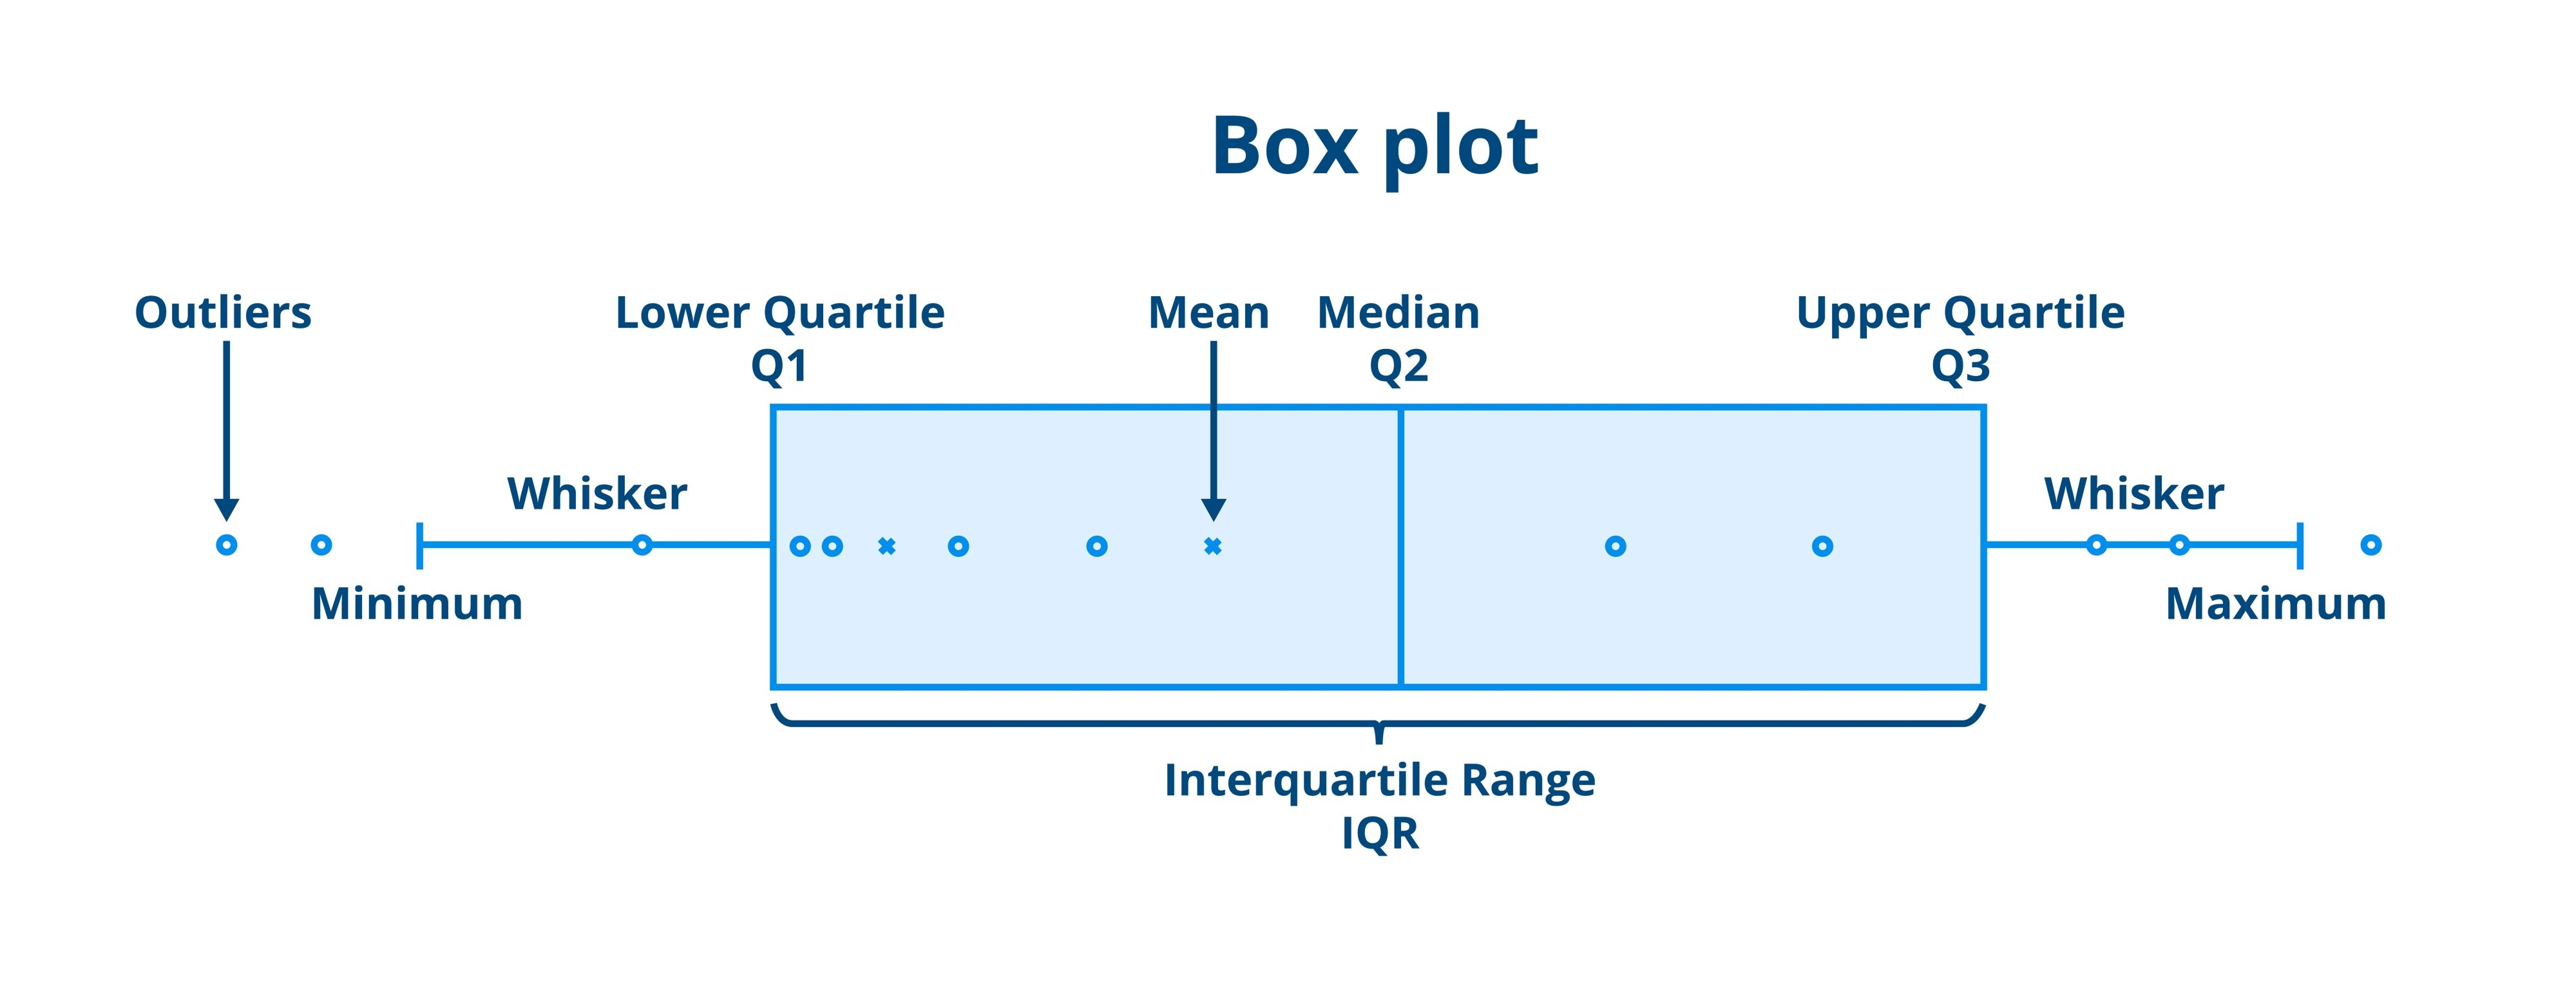

**¿Cuándo es ideal utilizarlos?**

Es uno de los gráficos favoritos en la ciencia de datos por su capacidad de síntesis. Es especialmente útil en los siguientes casos:

* **Identificación de outliers**: Es la mejor herramienta visual para detectar valores atípicos (esos puntos que quedan fuera de los "bigotes") que podrían sesgar un análisis.

* **Comparación de grupos**: Permite comparar rápidamente la dispersión y la mediana de diferentes categorías (por ejemplo, comparar los puntajes de matemáticas entre distintos grupos de preparación).

* **Simetría y sesgo**: Ayuda a ver si los datos están concentrados en los valores bajos, en los altos o si se distribuyen de forma uniforme.

* **Ahorro de espacio**: Puedes poner 10 boxplots uno al lado del otro para comparar 10 categorías distintas y la gráfica seguirá siendo perfectamente legible.

**Dato clave:** La "caja" representa el rango intercuartílico (IQR), donde se encuentra el 50% central de tus datos. Si la caja es muy larga, los datos están muy dispersos; si es corta, están muy concentrados.

In [ ]:
sns.boxplot(x='race/ethnicity', y='reading score', data=df)
#plt.title('Distribución de Tarifas por Puerto de Embarque')
plt.xlabel('race/ethnicity')
plt.ylabel('math score')
plt.show()

# **7. Gráfico de Violin (Violin Plot)**


Un gráfico de violín es esencialmente una evolución del boxplot. Combina la información estadística de una caja y bigotes con un diagrama de densidad de kernel (KDE).

Básicamente, es como si pusieras un boxplot en el centro y le pegaras a los lados una silueta que representa qué tan frecuentes son los valores en cada punto. Mientras más ancha sea la "panza" del violín, más datos hay concentrados en ese nivel.

**¿Cuándo es ideal utilizarlos?**
Es la herramienta definitiva cuando los boxplots se quedan "cortos" en información. Úsalos en estos casos:

* **Distribuciones multimodales**: Si tus datos tienen dos o más picos de concentración (por ejemplo, notas que se agrupan en "muy alto" y "muy bajo"), un boxplot solo te mostrará una caja aburrida. El violín, en cambio, mostrará claramente los dos ensanchamientos.

* **Grandes volúmenes de datos:** Cuando tienes miles de registros, los puntos individuales (outliers) pueden saturar un gráfico, pero la silueta del violín te permite ver la masa de los datos de forma fluida.

* **Análisis estético y profesional:** En reportes avanzados o publicaciones científicas, ofrecen una visión mucho más rica y moderna de la estructura de los datos que un gráfico de barras o un boxplot tradicional.

* **Comparación de densidades:** Son excelentes para ver si una categoría está más "dispersa" o "concentrada" que otra de un solo vistazo.

**Nota técnica:** A diferencia del boxplot, el violín no te permite identificar puntos atípicos (outliers) individuales con tanta facilidad a menos que le añadas los puntos originales encima (un "swarm plot" o "strip plot").

In [ ]:

sns.violinplot(x='race/ethnicity', y='math score', data=df)
plt.xticks(rotation=90)
plt.show()

In [ ]:
#sns.countplot(x='Survived', hue='Sex', data=df)
sns.countplot(x='race/ethnicity', hue='gender', data=df)
#plt.title('Survival by Gender')
#plt.xticks([0, 1], ['No', 'Yes'])
plt.show()


In [ ]:
df['gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()
